<a href="https://colab.research.google.com/github/COMP3608-Group-12/Project/blob/Dataset-1-Result-Visualizations/Group_12_Dataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Initial test commit

## STEP 1: Importing Packages

In [2]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import imblearn

## STEP 2: Load & Understand Data

In [3]:
#MUST BE RUN inorder for file download to work
!pip install gdown

#Download dataset csv into runtime from google drive link
import gdown

url = "https://drive.google.com/uc?id=1mFcMnqHO11_g5Fw-t9TOQPWSj59WZ_t9"
gdown.download(url, "creditcard.csv", quiet=False)

#loading csv file into pandas dataframe
df = pd.read_csv('creditcard.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1mFcMnqHO11_g5Fw-t9TOQPWSj59WZ_t9
From (redirected): https://drive.google.com/uc?id=1mFcMnqHO11_g5Fw-t9TOQPWSj59WZ_t9&confirm=t&uuid=03d84168-3b18-4381-b265-345201af4187
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:03<00:00, 49.5MB/s]


In [4]:
#printing dataset information (how many rows, columns etc)
print(df.info())
print('----------------------------------------------------------')

#checking if any values are missing
print(df.isnull().sum())
print('----------------------------------------------------------')

# Show ONLY columns with missing values
print("Columns with missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print('----------------------------------------------------------')

#Dropping rows with missing values
df = df.dropna()

#Verifying that those rows have been dropped and there are no missing values
print("Total missing values after dropping:")
print(df.isnull().sum().sum())  # should be 0
print('----------------------------------------------------------')

#previewing the data
print(df.head(5))
print('----------------------------------------------------------')

#checking how many transactions are fraudulent and how many are non-fraudulent
print(df['Class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Step 3: Split Data into Features & Target

In [5]:
#Splitting features and target
X = df.drop('Class', axis=1)
y = df['Class']

##Step 4: Decision Tree Model using KFold Cross Validation

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

#Decision Tree Model
model_dt = DecisionTreeClassifier(random_state=42)

# StratifiedKFold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store results
all_results = []

all_y_true_dt = []
all_y_prob_dt = []
all_y_pred_dt = []

# Manual KFold Loop
for fold, (train_index, test_index) in enumerate(kf.split(X, y), 1):

    print(f"\n================== Fold {fold} ==================")

    # Split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Train model
    model_dt.fit(X_train_resampled, y_train_resampled)

    # Predict on test data
    y_pred = model_dt.predict(X_test)
    y_prob = model_dt.predict_proba(X_test)[:, 1]

    all_y_true_dt.extend(y_test)
    all_y_prob_dt.extend(y_prob)
    all_y_pred_dt.extend(y_pred)

    #Performance metrics
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    results_df = pd.DataFrame({
        "Metric": list(results.keys()),
        "Value": [round(value, 4) for value in results.values()]
    })

    print(results_df)

    print(f"\n============================================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"\n============================================")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Appending results
    all_results.append(results)

# Taking average of all results
results_df = pd.DataFrame(all_results)

avg_results = results_df.mean()
std_results = results_df.std()

final_df = pd.DataFrame({
    "Metric": avg_results.index,
    "Average Value": [round(val, 4) for val in avg_results.values],
    "Std Dev": [round(val, 4) for val in std_results.values]
})

print("\n================== AVERAGE PERFORMANCE ==================")
print(final_df)


================== Fold 1 ==================
      Metric   Value
0   Accuracy  0.9975
1  Precision  0.3814
2     Recall  0.7551
3   F1 Score  0.5068
4    ROC-AUC  0.8765

Confusion Matrix:
[[28372    60]
 [   12    37]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9979    0.9987     28432
           1     0.3814    0.7551    0.5068        49

    accuracy                         0.9975     28481
   macro avg     0.6905    0.8765    0.7528     28481
weighted avg     0.9985    0.9975    0.9979     28481


================== Fold 2 ==================
      Metric   Value
0   Accuracy  0.9981
1  Precision  0.4684
2     Recall  0.7551
3   F1 Score  0.5781
4    ROC-AUC  0.8768

Confusion Matrix:
[[28390    42]
 [   12    37]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9985    0.9990     28432
           1     0.4684    0.7551    0.5781        49

    accuracy     

## Step 6: Deep Neural Network using K-Fold Cross Validation

In [7]:
#Runtime roughly around 14-15 minutes

#Importing relavent packages
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


#Creating DNN Model
def create_dnn_model(input_dim):
  model = models.Sequential([
    Input(shape = (input_dim,)),

    layers.Dense(32, activation = 'relu'),
    layers.BatchNormalization(),                                                    #Normalize outputs

    layers.Dense(16, activation = 'relu'),
    layers.Dropout(0.2),                                                           #Prevents overfitting (20% dropoff)

    layers.Dense(8, activation = 'relu'),

    layers.Dense(1, activation = 'sigmoid')
  ])

  model.compile(
      optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
      loss = 'binary_crossentropy',
      metrics = [
          tf.keras.metrics.Precision(),
          tf.keras.metrics.Recall(),
          tf.keras.metrics.AUC()
      ]
  )
  return model


##K-Fold Setup, Training Model, Predicting and Metrics

#K-Fold setup
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

all_results = []

all_y_true_dnn = []
all_y_prob_dnn = []
all_y_pred_dnn = []

#Manual K-Fold loop
for fold, (train_index, test_index) in enumerate(kf.split(X, y), 1):
    print(f"\n================== Fold {fold} ==================")

    # Split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    #Scaling Data
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    # SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


    #Training Model
    model = create_dnn_model(input_dim = X_train_resampled.shape[1])

    history = model.fit(
        X_train_resampled, y_train_resampled,
        epochs = 10,
        batch_size = 256,
        validation_split = 0.2,
        verbose = 1
    )

    #Predicting
    y_prob = model.predict(X_test_scaled, verbose = 1).flatten()
    y_pred = (y_prob > 0.5).astype(float)

    all_y_true_dnn.extend(y_test)
    all_y_prob_dnn.extend(y_prob)
    all_y_pred_dnn.extend(y_pred)

    #Performance Metrics
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    results_df_dnn_dataset1 = pd.DataFrame({"Metric": list(results.keys()), "Value": [round(value, 4) for value in results.values()]})
    print(results_df_dnn_dataset1)

    print("\n Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\n Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))


    #Appending all results
    all_results.append(results)


#Tabulated Average of Results
results_df_dnn_dataset1  = pd.DataFrame(all_results)
avg_results_dnn_dataset1 = results_df_dnn_dataset1.mean()
std_results_dnn_dataset1 = results_df_dnn_dataset1.std()
final_df_dnn_dataset1    = pd.DataFrame({"Metric": avg_results_dnn_dataset1.index,
                                         "Average Value": [round(val, 4) for val in avg_results_dnn_dataset1.values],
                                         "Std Dev": [round(val, 4) for val in std_results_dnn_dataset1.values],
                                         })

print("\n================== AVERAGE PERFORMANCE ==================")
print(final_df_dnn_dataset1.to_string(index=False))



================== Fold 1 ==================
Epoch 1/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - auc: 0.9934 - loss: 0.1053 - precision: 0.9348 - recall: 0.9582 - val_auc: 0.0000e+00 - val_loss: 0.0216 - val_precision: 1.0000 - val_recall: 0.9954
Epoch 2/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - auc: 0.9995 - loss: 0.0229 - precision: 0.9873 - recall: 0.9931 - val_auc: 0.0000e+00 - val_loss: 0.0079 - val_precision: 1.0000 - val_recall: 0.9999
Epoch 3/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - auc: 0.9996 - loss: 0.0152 - precision: 0.9917 - recall: 0.9962 - val_auc: 0.0000e+00 - val_loss: 0.0063 - val_precision: 1.0000 - val_recall: 0.9989
Epoch 4/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - auc: 0.9997 - loss: 0.0120 - precision: 0.9935 - recall: 0.9971 - val_auc: 0.0000e+00 - val_loss: 0.0052 - val_precision: 1.0000 - val_recall: 0.9998
Epoch 5/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - auc: 0.9997 - loss: 0.0103 - precision: 0.9947 - recall: 0.9975 - val_auc

## Step 7: Logistic Regression with K Fold Cross Validation

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

#Logistic Regression Model
model_lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)

# StratifiedKFold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store results
lr_fold_results = []

all_y_true_lr = []
all_y_prob_lr = []
all_y_pred_lr = []

#Threshold was added bc initial run the precision was very low
threshold = 0.8

# Manual KFold Loop
for fold, (train_index, test_index) in enumerate(kf.split(X, y), 1):

    print(f"\n================== Fold {fold} ==================")

    # Split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    #Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # Train model
    model_lr.fit(X_train_resampled, y_train_resampled)

    # Predict on test data
    y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    all_y_true_lr.extend(y_test)
    all_y_prob_lr.extend(y_prob)
    all_y_pred_lr.extend(y_pred)

     #Performance metrics
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    results_df = pd.DataFrame({
        "Metric": list(results.keys()),
        "Value": [round(value, 4) for value in results.values()]
    })

    print(results_df)

    print(f"\n============================================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"\n============================================")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Appending results
    lr_fold_results.append(results)

# Taking average of all results
lr_results_df = pd.DataFrame(lr_fold_results)

avg_results_lr = lr_results_df.mean()
std_results_lr = lr_results_df.std()

final_results_lr = pd.DataFrame({
    "Metric": avg_results_lr.index,
    "Average Value": [round(val, 4) for val in avg_results_lr.values],
    "Std Dev": [round(val, 4) for val in std_results_lr.values]
})

print("\n================== AVERAGE PERFORMANCE ==================")
print(final_results_lr)



================== Fold 1 ==================
      Metric   Value
0   Accuracy  0.9909
1  Precision  0.1409
2     Recall  0.8367
3   F1 Score  0.2412
4    ROC-AUC  0.9848

Confusion Matrix:
[[28182   250]
 [    8    41]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9912    0.9954     28432
           1     0.1409    0.8367    0.2412        49

    accuracy                         0.9909     28481
   macro avg     0.5703    0.9140    0.6183     28481
weighted avg     0.9982    0.9909    0.9941     28481


================== Fold 2 ==================
      Metric   Value
0   Accuracy  0.9925
1  Precision  0.1706
2     Recall  0.8776
3   F1 Score  0.2857
4    ROC-AUC  0.9956

Confusion Matrix:
[[28223   209]
 [    6    43]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9926    0.9962     28432
           1     0.1706    0.8776    0.2857        49

    accuracy     

##Step 8: Visualizing Results


###Step 8a: Table Showing Collated Average Performance Metrics & Standard Deviation


In [37]:
# Set Metric as index
dt_df = final_df.set_index("Metric")
lr_df = final_results_lr.set_index("Metric")
dnn_df = final_df_dnn_dataset1.set_index("Metric")

# Combining mean ± std dev
summary_table = pd.concat([
    (dt_df["Average Value"].round(4).astype(str) + " ± " + dt_df["Std Dev"].round(4).astype(str)).rename("Decision Tree"),
    (lr_df["Average Value"].round(4).astype(str) + " ± " + lr_df["Std Dev"].round(4).astype(str)).rename("Logistic Regression"),
    (dnn_df["Average Value"].round(4).astype(str) + " ± " + dnn_df["Std Dev"].round(4).astype(str)).rename("Deep Neural Network")
], axis=1).T

# Displaying data in styled table
styled_table = (
    summary_table.style
    .set_caption("Model Performance Comparison (Mean ± Std)")
    .set_table_styles([
        # Caption
        {'selector': 'caption',
         'props': [('font-size', '18px'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center'),
                   ('margin-bottom', '10px')]},

        # Header
        {'selector': 'th',
         'props': [('font-size', '15px'),
                   ('text-align', 'center'),
                   ('background-color', '#2c3e50'),
                   ('color', 'white'),
                   ('padding', '15px')]},

        # Data cells
        {'selector': 'td',
         'props': [('text-align', 'center'),
                   ('padding', '15px'),
                   ('border', '1px solid #ddd')]},

    ])
)

display(styled_table)

Metric,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,0.9979 ± 0.0002,0.4422 ± 0.033,0.7966 ± 0.0368,0.5683 ± 0.0342,0.8974 ± 0.0185
Logistic Regression,0.9911 ± 0.0007,0.1509 ± 0.0119,0.886 ± 0.0376,0.2577 ± 0.0182,0.9784 ± 0.0119
Deep Neural Network,0.9984 ± 0.0003,0.5262 ± 0.0669,0.8435 ± 0.0442,0.6462 ± 0.0545,0.9625 ± 0.0196


###Step 8b: Barchart Showing Average Performance Metrics for the 3 Models

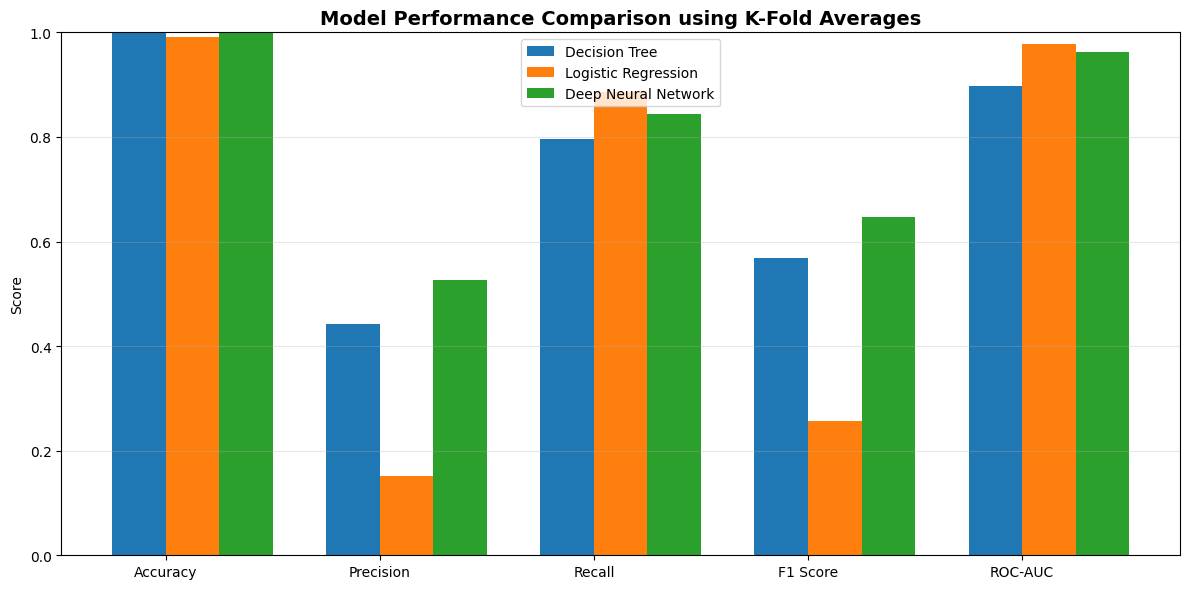

In [10]:
import matplotlib.pyplot as plt
import numpy as np

#Creating a summary of the average results of all three algorithms
results_summary = {
    "Decision Tree": final_df.set_index("Metric")["Average Value"],
    "Logistic Regression": final_results_lr.set_index("Metric")["Average Value"],
    "Deep Neural Network": final_df_dnn_dataset1.set_index("Metric")["Average Value"]
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
models = list(results_summary.keys())

#Barchart
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12,6))

for i, model in enumerate(models):
    values = [results_summary[model][m] for m in metrics]
    plt.bar(x + i*width, values, width=width, label=model)

plt.xticks(x + width/2, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison using K-Fold Averages", fontsize=14, fontweight='bold')
plt.ylim(0,1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

###Step 8c: AUC-ROC Curves using Aggregated K Fold Results

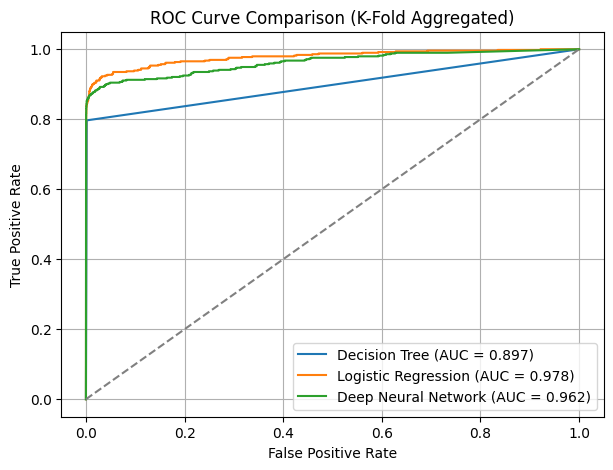

In [11]:
#AUC-ROC Curves for 3 algorithms
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(all_y_true_dt, all_y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(all_y_true_lr, all_y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Deep Neural Network
fpr_dnn, tpr_dnn, _ = roc_curve(all_y_true_dnn, all_y_prob_dnn)
auc_dnn = auc(fpr_dnn, tpr_dnn)
plt.plot(fpr_dnn, tpr_dnn, label=f"Deep Neural Network (AUC = {auc_dnn:.3f})")

# Plotting curves

#Drawing baseline
plt.plot([0,1], [0,1], '--', color='gray')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (K-Fold Aggregated)")
plt.legend()
plt.grid()

plt.show()

###Step 8d: Precision-Recall Curves


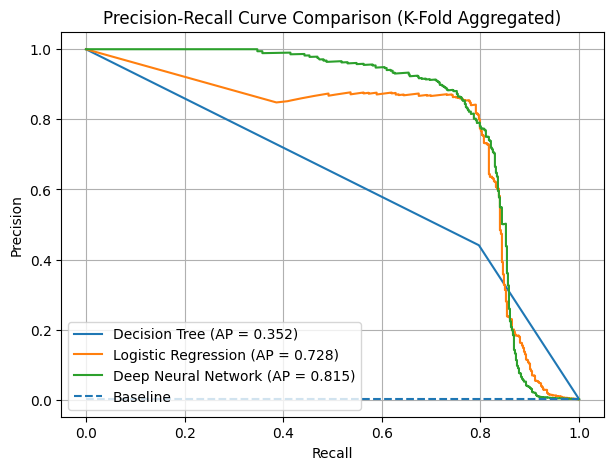

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Decision Tree
prec_dt, rec_dt, _ = precision_recall_curve(all_y_true_dt, all_y_prob_dt)
ap_dt = average_precision_score(all_y_true_dt, all_y_prob_dt)
plt.plot(rec_dt, prec_dt, label=f"Decision Tree (AP = {ap_dt:.3f})")

# Logistic Regression
prec_lr, rec_lr, _ = precision_recall_curve(all_y_true_lr, all_y_prob_lr)
ap_lr = average_precision_score(all_y_true_lr, all_y_prob_lr)
plt.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")

# Deep Neural Network
prec_dnn, rec_dnn, _ = precision_recall_curve(all_y_true_dnn, all_y_prob_dnn)
ap_dnn = average_precision_score(all_y_true_dnn, all_y_prob_dnn)
plt.plot(rec_dnn, prec_dnn, label=f"Deep Neural Network (AP = {ap_dnn:.3f})")

# Plotting curves

# Drawing baseline
baseline = sum(all_y_true_lr) / len(all_y_true_lr)
plt.hlines(baseline, 0, 1, linestyles='--', label='Baseline')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison (K-Fold Aggregated)")
plt.legend()
plt.grid()

plt.show()

###Step 8e: Confusion Matrices (Heatmaps)


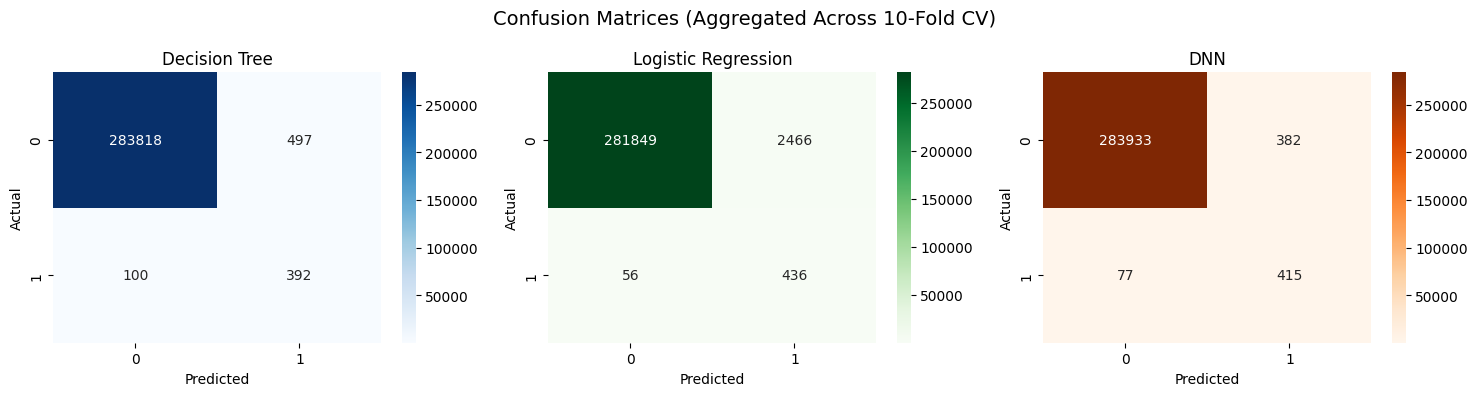

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_dt = confusion_matrix(all_y_true_dt, all_y_pred_dt)
cm_lr = confusion_matrix(all_y_true_lr, all_y_pred_lr)
cm_dnn = confusion_matrix(all_y_true_dnn, all_y_pred_dnn)

# Plot all in one figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Decision Tree")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Deep Neural Network
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title("DNN")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.suptitle("Confusion Matrices (Aggregated Across 10-Fold CV)", fontsize=14)
plt.tight_layout()
plt.show()